In [1]:
# All Newman-alpha-scheme machinery (centering, Jacobians, LCF/spectral-gap
# computation, sync/async updates, MLE fitting, SBM data generation) now
# lives in utils.py -- see that file for full documentation of each function.
# utils.py must be in the same directory as this notebook (or on sys.path).
from utils import *

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import to_rgb, to_hex
from matplotlib.lines import Line2D

# Monkey data

In [2]:
df = pd.read_csv('data/dominance_data.csv')

# 1. Remove rows without clear winner/loser
df_clean = df[(df['winner'] != 0) & (df['loser'] != 0)].copy()

# 2. Keep individuals with at least one win AND one loss
win_counts = df_clean['winner'].value_counts()
loss_counts = df_clean['loser'].value_counts()

active_names = sorted(
    set(win_counts.index).intersection(set(loss_counts.index))
)

df_active = df_clean[
    df_clean['winner'].isin(active_names) &
    df_clean['loser'].isin(active_names)
].copy()

# 3. Build directed graph
G = nx.DiGraph()
G.add_edges_from(zip(df_active['winner'], df_active['loser']))

# 4. Extract largest strongly connected component
largest_scc = max(nx.strongly_connected_components(G), key=len)

df_final = df_active[
    df_active['winner'].isin(largest_scc) &
    df_active['loser'].isin(largest_scc)
].copy()

# 5. Rebuild ID mapping
final_names = sorted(largest_scc)
label_to_id = {name: i for i, name in enumerate(final_names)}
id_to_label = {i: name for name, i in label_to_id.items()}
n = len(final_names)

# 6. Construct W
W = np.zeros((n, n))
for _, row in df_final.iterrows():
    w_id = label_to_id[row['winner']]
    l_id = label_to_id[row['loser']]
    W[w_id, l_id] += 1

# --- Final Stats ---
print(f"Participants kept (largest SCC): {n}")
print(f"Total interactions processed: {len(df_final)}")


win_list = {i: [np.where(W[i] > 0)[0], W[i][W[i] > 0]] for i in range(n)}
loss_list = {i: [np.where(W[:, i] > 0)[0], W[:, i][W[:, i] > 0]] for i in range(n)}

Participants kept (largest SCC): 64
Total interactions processed: 11632


In [3]:
mle = newman_fpi(win_list, loss_list, alpha = 0, sync = 'none', maxiter=5000)

In [4]:
def population_W(W, pi):
    # Expected comparison matrix under BT, counts inferred from W.
    # bar_W[i,j] = (W[i,j]+W[j,i]) * pi[i]/(pi[i]+pi[j]).
    pi = np.asarray(pi, dtype=float)
    N  = W + W.T                                      # total comparisons per edge
    P  = pi[:, None] / (pi[:, None] + pi[None, :])    # pi_i / (pi_i + pi_j)
    bar_W = N * P
    np.fill_diagonal(bar_W, 0)
    return bar_W

bar_W   = population_W(W, mle)
rel_err = np.linalg.norm(W - bar_W, ord=2) / np.linalg.norm(W, ord=2)
print(f"||W - bar_W||_2 / ||W||_2 = {rel_err:.6f}")

||W - bar_W||_2 / ||W||_2 = 0.181133


In [5]:
alpha_set = np.linspace(0,1,20)

rates_f = np.array([get_lcf(W, mle, alpha, sync = 'full') for alpha in alpha_set])
gaps_f = np.array([get_gap(W, mle, alpha, sync = 'full') for alpha in alpha_set])

rates_a = np.array([get_lcf(W, mle, alpha, sync = 'none') for alpha in alpha_set])
gaps_a = np.array([get_gap(W, mle, alpha, sync = 'none') for alpha in alpha_set])

In [6]:
print("Sync:")
print(f"  rho(0)     = {get_lcf(W, mle, 0, sync='full'):.6f},  rho_bar(0) = {1 - get_gap(W, mle, 0, 'full'):.6f}")
print(f"  rho(1)     = {get_lcf(W, mle, 1, sync='full'):.6f},  rho_bar(1) = {1 - get_gap(W, mle, 1, 'full'):.6f}")

print("Async:")
print(f"  rho(0)     = {get_lcf(W, mle, 0, sync='none'):.6f},  rho_bar(0) = {1 - get_gap(W, mle, 0, 'none'):.6f}")
print(f"  rho(1)     = {get_lcf(W, mle, 1, sync='none'):.6f},  rho_bar(1) = {1 - get_gap(W, mle, 1, 'none'):.6f}")

Sync:
  rho(0)     = 0.661777,  rho_bar(0) = 0.657724
  rho(1)     = 0.960341,  rho_bar(1) = 0.960383
Async:
  rho(0)     = 0.460023,  rho_bar(0) = 0.445718
  rho(1)     = 0.959340,  rho_bar(1) = 0.959389


In [7]:
# --- Shared style config ---
FIG_W, FIG_H  = 16.5, 14
TITLE_FS      = 54
LABEL_FS      = 42
TICK_FS       = 32
LEGEND_FS     = 30
MARKER_S      = 180
CI_ALPHA      = 0.15

COLOR_SYNC    = '#2166AC'
COLOR_ASYNC   = '#D6604D'

rc('text', usetex=True)
rc('font', family='serif')
rc('axes', linewidth=0.8)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

# Convergence rates -- square markers
ax.scatter(alpha_set, rates_f, label=r'$\rho_{\mathrm{sync}}$',
                color=COLOR_SYNC,  s=MARKER_S,   marker='s', zorder=3, alpha=0.8, facecolors='none')
ax.plot(alpha_set, rates_f, color=COLOR_SYNC, linewidth=1, zorder=2)

ax.scatter(alpha_set, 1 - gaps_f, label=r'$\bar\rho_{\mathrm{sync}}$',
        color=COLOR_SYNC,  s=MARKER_S*2 + 40, marker='+', linewidths=1.5, zorder=3)
ax.plot(alpha_set, 1 - gaps_f, color=COLOR_SYNC, linewidth=1, linestyle='--', zorder=2)

# Gap predictions -- plus markers
ax.scatter(alpha_set, rates_a, label=r'$\rho_{\mathrm{async}}$',
        color=COLOR_ASYNC, s=MARKER_S,   marker='s', zorder=3, alpha=0.8, facecolors='none')
ax.plot(alpha_set, rates_a, color=COLOR_ASYNC, linewidth=1, zorder=2)

ax.scatter(alpha_set, 1 - gaps_a, label=r'$\bar\rho_{\mathrm{async}}$',
        color=COLOR_ASYNC, s=MARKER_S*2, marker='+', linewidths=1.5, zorder=3)
ax.plot(alpha_set, 1 - gaps_a, color=COLOR_ASYNC, linewidth=1, linestyle='--', zorder=2)


legend_elements = [
            Line2D([0,1], [0,0], color=COLOR_SYNC,  marker='s', markersize=10,
                markerfacecolor='none', markeredgecolor=COLOR_SYNC,
                linestyle='-',  linewidth=1, label=r'$\rho_{\mathrm{sync}}$'),
            Line2D([0,1], [0,0], color=COLOR_SYNC,  marker='+', markersize=12,
                markeredgewidth=1.5,
                linestyle='--', linewidth=1, label=r'$\bar\rho_{\mathrm{sync}}$'),
            Line2D([0,1], [0,0], color=COLOR_ASYNC, marker='s', markersize=10,
                markerfacecolor='none', markeredgecolor=COLOR_ASYNC,
                linestyle='-',  linewidth=1, label=r'$\rho_{\mathrm{async}}$'),
            Line2D([0,1], [0,0], color=COLOR_ASYNC, marker='+', markersize=12,
                markeredgewidth=1.5,
                linestyle='--', linewidth=1, label=r'$\bar\rho_{\mathrm{async}}$'),
        ]


ax.set_title(r"$\mathrm{Vervet}$", fontsize=TITLE_FS, color='black', pad=30)
ax.set_xlabel(r'$\alpha$', fontsize=LABEL_FS)
# --- Referee comment: unify y-axis label from 'Rate' to 'Convergence factor' ---
ax.set_ylabel(r'Convergence factor', fontsize=LABEL_FS, labelpad=20)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, linewidth=0.4, alpha=0.4)

ax.legend(handles=legend_elements, fontsize=LEGEND_FS, loc='lower right',
          bbox_to_anchor=(0.98, 0.02), framealpha=0.85, edgecolor='gray')

# plt.tight_layout(pad=0.5)
plt.savefig("vervet_rates.pdf")
plt.close()

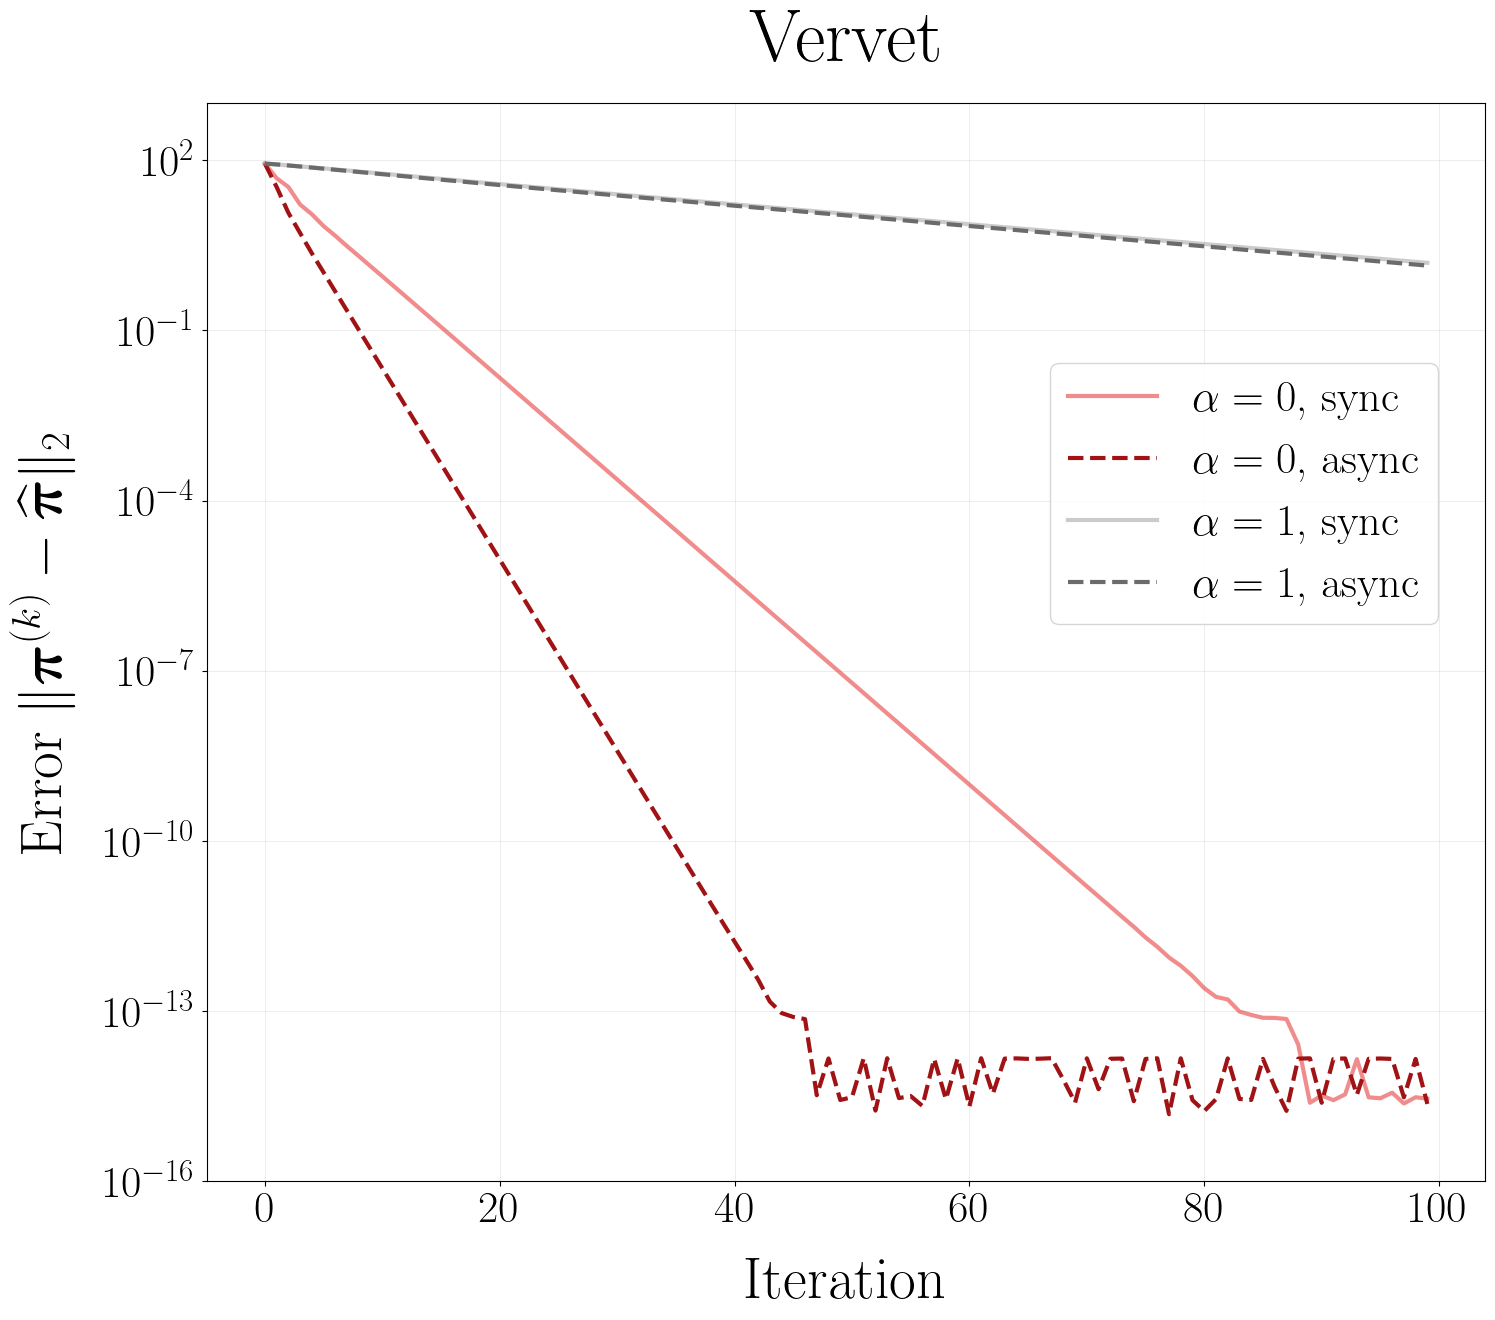

In [8]:
N = 100
alphas = [0, 1]
base_colors = plt.cm.Set1(np.linspace(0, 1, len(alphas)))  # base color per alpha

def shade_color(color, factor):
    # lighter/darker shade of color (factor <1 darker, >1 lighter)
    r, g, b = to_rgb(color)
    r = min(max(r*factor,0),1)
    g = min(max(g*factor,0),1)
    b = min(max(b*factor,0),1)
    return (r, g, b)

rc('text', usetex=True)
rc('font', family='serif')
rc('text.latex', preamble=r'\usepackage{bm}')   # needed for \bm{} in the y-axis label below
plt.figure(figsize=(16.5, 14))

for i, a in enumerate(alphas):
    gamma = np.ones(n)

    sync = 'full'
    error_sync = []
    for _ in range(N):
        error_sync.append(np.linalg.norm(gamma - mle, ord=2))
        gamma = newman_update(gamma, win_list, loss_list, alpha=a, sync=sync)
    plt.semilogy(error_sync,
                 color=base_colors[i], linewidth=3, linestyle='-', alpha=0.5,
                 label=rf"$\alpha={a}$, sync")

    sync = 'none'
    gamma = np.ones(n)
    error_async = []
    for _ in range(N):
        error_async.append(np.linalg.norm(gamma - mle, ord=2))
        gamma = newman_update(gamma, win_list, loss_list, alpha=a, sync=sync)
    plt.semilogy(error_async,
                 color=shade_color(base_colors[i], 0.7), linewidth=3, linestyle='--',
                 label=rf"$\alpha={a}$, async")

plt.title(r"$\mathrm{Vervet}$", fontsize=54, color='black', pad=30)
plt.ylim(1e-16, 1e3)
plt.xlabel(r'Iteration', fontsize=42, labelpad=20)
# --- Referee comment: unify y-axis label across figures ---
plt.ylabel(r'Error $\|\bm{\pi}^{(k)}-\widehat{\bm{\pi}}\|_2$', fontsize=42, labelpad=20)
plt.tick_params(axis='both', which='major', labelsize=32)
plt.grid(True, linewidth=0.4, alpha=0.4)
plt.legend(fontsize=32, loc='upper right', bbox_to_anchor=(0.98, 0.78))
plt.savefig("vervet.pdf")
plt.show()

In [9]:
ff1 = get_slope_average(win_list, loss_list, mle, 0, sync = 'full', tol = 1e-10, maxiter = 10000, N = 10)
gg1 = get_slope_average(win_list, loss_list, mle, 0, sync = 'none', tol = 1e-10, maxiter = 10000, N = 10)
gg2 = get_slope_average(win_list, loss_list, mle, 1, sync = 'full', tol = 1e-10, maxiter = 10000, N = 10)
print(np.log10(ff1[0])/np.log10(gg2[0]), np.log10(gg1[0])/np.log10(gg2[0]))

10.268269432041091 19.313884124025705


In [10]:
print(np.log10(1-get_gap(W, mle, alpha = 0, sync = 'full'))/np.log10(1-get_gap(W, mle, alpha = 1, sync = 'full')), \
      np.log10(1-get_gap(W, mle, alpha = 0, sync = 'none'))/np.log10(1-get_gap(W, mle, alpha = 1, sync = 'full')))

10.364703351988492 19.990462455271768
